In [1]:
# ============================================
# 1. IMPORT LIBRARY
# ============================================

# Library untuk mengolah data
import pandas as pd
import numpy as np

# Library untuk membuat visualisasi
import matplotlib.pyplot as plt

# Library Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Library untuk menampilkan tabel dengan format yang lebih rapi
from IPython.display import display

# 1. Library

Tahap pertama dalam proses **Principal Component Analysis (PCA)** adalah mengimpor seluruh library yang diperlukan. Library tersebut digunakan untuk membantu proses membaca dataset, melakukan pengolahan data, menerapkan metode PCA, serta menampilkan hasil analisis dalam bentuk tabel dan grafik.

Adapun fungsi dari setiap library yang digunakan adalah sebagai berikut:

- **Pandas** : Membaca dan mengolah dataset dalam bentuk DataFrame.
- **NumPy** : Membantu proses perhitungan numerik.
- **Matplotlib** : Membuat visualisasi hasil analisis.
- **StandardScaler** : Melakukan standardisasi data agar setiap fitur memiliki skala yang sama.
- **PCA** : Melakukan reduksi dimensi data menggunakan metode Principal Component Analysis.
- **display** : Menampilkan DataFrame dalam bentuk tabel yang lebih rapi.

In [2]:
# ============================================
# 2. MEMANGGIL DATASET
# ============================================

# Membaca dataset WineQT
data = pd.read_csv("WineQT.csv")

# Menampilkan 5 data pertama
print("5 Data Pertama Dataset WineQT")
display(data.head())

5 Data Pertama Dataset WineQT


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# 2. Memanggil Dataset

Pada tahap ini dilakukan proses membaca dataset **WineQT** yang akan digunakan dalam analisis. Dataset dibaca menggunakan fungsi `read_csv()` dari library **Pandas**.

Selanjutnya, lima baris pertama dari dataset ditampilkan menggunakan fungsi `head()` untuk memastikan bahwa data berhasil dimuat serta mengetahui struktur awal dataset, seperti nama kolom dan isi data.

Output yang ditampilkan berupa tabel sehingga memudahkan proses identifikasi atribut yang akan digunakan pada tahap berikutnya.

In [3]:
# ============================================
# 3. INFORMASI DATASET
# ============================================

# Menampilkan ukuran dataset
print("Ukuran Dataset")
print(f"Jumlah Baris : {data.shape[0]}")
print(f"Jumlah Kolom : {data.shape[1]}")

# Membuat tabel informasi dataset
info_dataset = pd.DataFrame({
    "Nama Kolom": data.columns,
    "Tipe Data": data.dtypes.astype(str),
    "Jumlah Data": data.count().values
})

print("\nInformasi Dataset")
display(info_dataset)

Ukuran Dataset
Jumlah Baris : 1143
Jumlah Kolom : 13

Informasi Dataset


,Nama Kolom,Tipe Data,Jumlah Data
fixed acidity,fixed acidity,float64,1143
volatile acidity,volatile acidity,float64,1143
citric acid,citric acid,float64,1143
residual sugar,residual sugar,float64,1143
chlorides,chlorides,float64,1143
free sulfur dioxide,free sulfur dioxide,float64,1143
total sulfur dioxide,total sulfur dioxide,float64,1143
density,density,float64,1143
pH,pH,float64,1143
sulphates,sulphates,float64,1143


# 3. Informasi Dataset

Pada tahap ini dilakukan pengecekan informasi dasar dari dataset yang akan digunakan dalam proses **Principal Component Analysis (PCA)**.

Informasi yang ditampilkan meliputi:

- **Jumlah baris** dan **jumlah kolom** pada dataset menggunakan atribut `shape`.
- **Nama setiap kolom**, **tipe data**, dan **jumlah data** pada masing-masing kolom dalam bentuk tabel.

Tahap ini bertujuan untuk memastikan bahwa dataset memiliki struktur yang sesuai dan seluruh data telah terbaca dengan benar sebelum dilakukan proses analisis pada tahap berikutnya.

In [4]:
# ============================================
# 4. STATISTIK DESKRIPTIF
# ============================================

# Menampilkan statistik deskriptif dataset
print("Statistik Deskriptif Dataset")

display(data.describe())

Statistik Deskriptif Dataset


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# 4. Statistik Deskriptif

Pada tahap ini dilakukan analisis statistik deskriptif untuk mengetahui gambaran umum dari setiap fitur numerik pada dataset.

Statistik yang ditampilkan meliputi:

- **count** : Jumlah data pada setiap kolom.
- **mean** : Nilai rata-rata.
- **std** : Standar deviasi yang menunjukkan tingkat penyebaran data.
- **min** : Nilai minimum.
- **25%** : Kuartil pertama.
- **50%** : Nilai tengah (median).
- **75%** : Kuartil ketiga.
- **max** : Nilai maksimum.

Tahap ini bertujuan untuk memahami karakteristik data sebelum dilakukan proses preprocessing dan penerapan metode PCA.

In [5]:
# ============================================
# 5. MENGECEK MISSING VALUE
# ============================================

# Mengecek jumlah missing value pada setiap kolom
missing_value = pd.DataFrame({
    "Nama Kolom": data.columns,
    "Jumlah Missing Value": data.isnull().sum().values
})

print("Missing Value Dataset")

display(missing_value)

Missing Value Dataset


,Nama Kolom,Jumlah Missing Value
0,fixed acidity,0
1,volatile acidity,0
2,citric acid,0
3,residual sugar,0
4,chlorides,0
5,free sulfur dioxide,0
6,total sulfur dioxide,0
7,density,0
8,pH,0
9,sulphates,0


# 5. Missing Value

Pada tahap ini dilakukan pengecekan **missing value** untuk mengetahui apakah terdapat data yang kosong pada setiap kolom dalam dataset.

Pengecekan dilakukan menggunakan fungsi `isnull().sum()`, kemudian hasilnya disajikan dalam bentuk tabel agar lebih mudah dibaca.

Tahap ini bertujuan untuk memastikan bahwa dataset tidak memiliki data yang hilang sehingga proses analisis menggunakan metode **Principal Component Analysis (PCA)** dapat dilakukan dengan baik.

In [6]:
# ============================================
# 6. MEMILIH FEATURE
# ============================================

# Memilih fitur yang akan digunakan pada PCA
X = data.drop(columns=["quality", "Id"])

print("Feature yang Digunakan")

display(X.head())

Feature yang Digunakan


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


# 6. Memilih Feature

Pada tahap ini dilakukan proses pemilihan **feature** yang akan digunakan dalam metode **Principal Component Analysis (PCA)**.

Kolom **quality** dan **Id** tidak digunakan karena:

- **quality** merupakan target atau label pada dataset.
- **Id** hanya berfungsi sebagai identitas setiap data dan tidak memiliki pengaruh terhadap proses analisis.

Hasil dari tahap ini adalah sekumpulan fitur numerik yang akan digunakan pada proses standardisasi dan penerapan metode PCA.

In [7]:
# ============================================
# 7. STANDARDISASI DATA
# ============================================

# Membuat objek StandardScaler
scaler = StandardScaler()

# Melakukan standardisasi data
X_scaled = scaler.fit_transform(X)

# Mengubah hasil standardisasi menjadi DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Hasil Standardisasi Data")

display(X_scaled.head())

Hasil Standardisasi Data


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382


# 7. Standardisasi Data

Pada tahap ini dilakukan proses **standardisasi data** menggunakan `StandardScaler`.

Standardisasi bertujuan untuk menyamakan skala setiap fitur sehingga memiliki nilai rata-rata (**mean**) sebesar 0 dan standar deviasi (**standard deviation**) sebesar 1.

Tahap ini sangat penting karena metode **Principal Component Analysis (PCA)** sensitif terhadap perbedaan skala antar fitur. Dengan melakukan standardisasi, setiap fitur memiliki kontribusi yang seimbang dalam proses pembentukan principal component.

In [8]:
# ============================================
# 8. MEMBUAT MODEL PCA
# ============================================

# Membuat model PCA dengan 2 Principal Component
pca = PCA(n_components=2)

# Melatih model PCA menggunakan data yang telah distandardisasi
pca.fit(X_scaled)

print("Model PCA berhasil dibuat dengan 2 Principal Component.")

Model PCA berhasil dibuat dengan 2 Principal Component.


# 8. Membuat Model PCA

Pada tahap ini dibuat model **Principal Component Analysis (PCA)** dengan jumlah komponen utama (**Principal Component**) sebanyak **2**.

Model kemudian dilatih menggunakan data yang telah distandardisasi melalui fungsi `fit()`. Proses ini bertujuan untuk mempelajari pola, hubungan antar fitur, serta menentukan arah komponen utama yang memiliki variasi data terbesar.

Hasil dari proses ini akan digunakan pada tahap berikutnya untuk mengubah data asli menjadi data dengan dimensi yang lebih rendah.

In [9]:
# ============================================
# 9. TRANSFORMASI PCA (transform)
# ============================================

# Mengubah data hasil standardisasi menjadi Principal Component
X_pca = pca.transform(X_scaled)

print("Data berhasil ditransformasikan menjadi Principal Component.")

Data berhasil ditransformasikan menjadi Principal Component.


# 9. Transformasi PCA

Pada tahap ini dilakukan proses transformasi data menggunakan model **Principal Component Analysis (PCA)** yang telah dilatih sebelumnya.

Fungsi `transform()` digunakan untuk mengubah data hasil standardisasi menjadi data baru dengan dimensi yang lebih rendah sesuai jumlah Principal Component yang telah ditentukan.

Hasil transformasi ini akan digunakan pada tahap berikutnya untuk menampilkan nilai **Principal Component (PC1 dan PC2)**.

In [10]:
# ============================================
# 10. HASIL PRINCIPAL COMPONENT
# ============================================

# Mengubah hasil transformasi menjadi DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("Hasil Principal Component")

display(pca_df.head())

Hasil Principal Component


,PC1,PC2
0,-1.561545,0.444892
1,-0.760892,1.915058
2,-0.708085,0.914423
3,2.308166,-0.224448
4,-1.561545,0.444892


# 10. Hasil Principal Component

Pada tahap ini ditampilkan hasil transformasi PCA dalam bentuk dua **Principal Component**, yaitu **PC1** dan **PC2**.

Setiap baris pada tabel merupakan representasi baru dari data asli setelah dilakukan proses reduksi dimensi menggunakan metode PCA.

Hasil ini akan digunakan untuk analisis lebih lanjut, seperti menghitung **Explained Variance** dan membuat visualisasi data.

In [11]:
# ============================================
# 11. EXPLAINED VARIANCE
# ============================================

# Menampilkan Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio")

display(pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": explained_variance
}))

Explained Variance Ratio


,Principal Component,Explained Variance Ratio
0,PC1,0.286923
1,PC2,0.170751


# 11. Explained Variance

Pada tahap ini ditampilkan nilai **Explained Variance Ratio** dari setiap Principal Component.

Nilai tersebut menunjukkan seberapa besar informasi atau variasi data yang dapat dijelaskan oleh masing-masing Principal Component.

Semakin besar nilai Explained Variance Ratio, maka semakin besar pula kontribusi Principal Component tersebut dalam merepresentasikan informasi dari dataset asli.

In [12]:
# ============================================
# 12. TOTAL EXPLAINED VARIANCE
# ============================================

# Menghitung total Explained Variance
total_variance = pca.explained_variance_ratio_.sum()

print("Total Explained Variance")

print(f"Total Explained Variance : {total_variance:.4f}")

Total Explained Variance
Total Explained Variance : 0.4577


# 12. Total Explained Variance

Pada tahap ini dihitung **Total Explained Variance** dengan menjumlahkan seluruh nilai **Explained Variance Ratio** dari setiap Principal Component.

Nilai ini menunjukkan seberapa besar informasi dari dataset asli yang masih dapat dipertahankan setelah dilakukan proses reduksi dimensi menggunakan metode PCA.

Semakin besar nilai Total Explained Variance, maka semakin banyak informasi penting dari data asli yang berhasil dipertahankan.

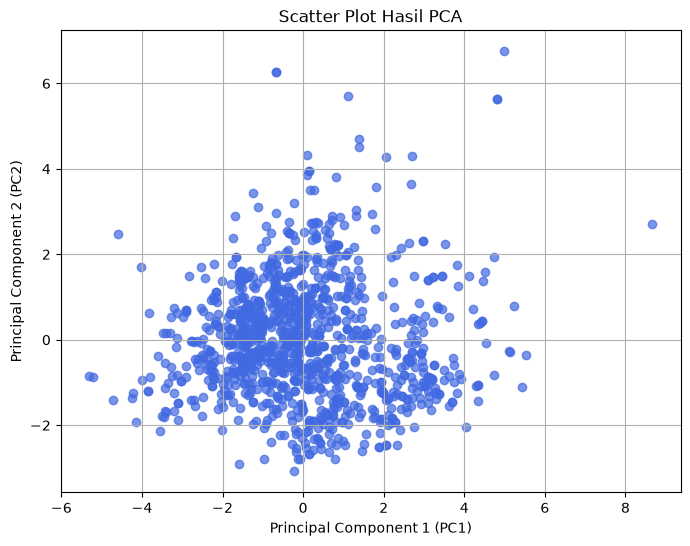

In [13]:
# ============================================
# 13. SCATTER PLOT PCA
# ============================================

# Membuat ukuran grafik
plt.figure(figsize=(8,6))

# Membuat scatter plot menggunakan PC1 dan PC2
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    color="royalblue",
    alpha=0.7
)

# Memberikan judul grafik
plt.title("Scatter Plot Hasil PCA")

# Memberikan nama pada sumbu X
plt.xlabel("Principal Component 1 (PC1)")

# Memberikan nama pada sumbu Y
plt.ylabel("Principal Component 2 (PC2)")

# Menampilkan garis bantu (grid)
plt.grid(True)

# Menampilkan grafik
plt.show()

# 13. Scatter Plot PCA

Pada tahap ini dilakukan visualisasi hasil reduksi dimensi menggunakan **Scatter Plot**.

Sumbu **X** menunjukkan **Principal Component 1 (PC1)**, sedangkan sumbu **Y** menunjukkan **Principal Component 2 (PC2)**.

Setiap titik pada grafik merepresentasikan satu data pada dataset **WineQT** yang telah direduksi menjadi dua dimensi menggunakan metode **Principal Component Analysis (PCA)**.

Visualisasi ini membantu melihat pola penyebaran data setelah proses reduksi dimensi dilakukan.

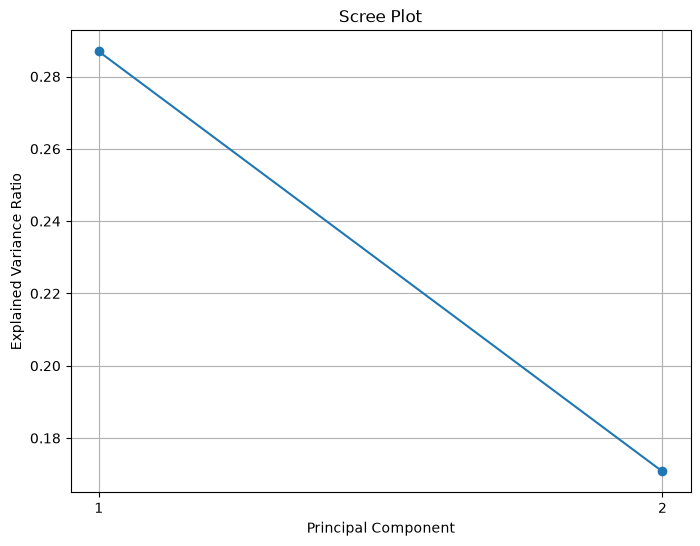

In [14]:
# ============================================
# 14. SCREE PLOT
# ============================================

# Membuat ukuran grafik
plt.figure(figsize=(8,6))

# Membuat Scree Plot berdasarkan Explained Variance Ratio
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)

# Memberikan judul grafik
plt.title("Scree Plot")

# Memberikan nama pada sumbu X
plt.xlabel("Principal Component")

# Memberikan nama pada sumbu Y
plt.ylabel("Explained Variance Ratio")

# Menampilkan nomor setiap Principal Component
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Menampilkan garis bantu (grid)
plt.grid(True)

# Menampilkan grafik
plt.show()

# 14. Scree Plot

Pada tahap ini dilakukan visualisasi **Explained Variance Ratio** menggunakan **Scree Plot**.

Sumbu **X** menunjukkan urutan **Principal Component (PC)**, sedangkan sumbu **Y** menunjukkan nilai **Explained Variance Ratio** dari setiap Principal Component.

Grafik ini digunakan untuk melihat kontribusi masing-masing Principal Component dalam menjelaskan variasi data. Principal Component dengan nilai **Explained Variance Ratio** yang lebih besar memiliki kontribusi yang lebih besar terhadap informasi yang dipertahankan dari dataset asli.